# Interpolator vs emulator: pure approximation residuals

Companion experiment to `kochukov2017.ipynb`. Both `IntensityLazyZarrInterpolator` and `IntensityPretrainedAemuSpectrumEmulator` are queried at the *native* grid points of the zarr cube. At those points the interpolator's bracket weights collapse onto a single corner, so it returns the stored spectrum exactly (no interpolation error) — every wavelength-by-wavelength difference is the emulator's pure approximation error.

In [1]:
from jax import config
config.update("jax_enable_x64", True)
import sys
sys.path.append('/Users/mjablons/code/spice/src')
from spice.spectrum.lazy_zarr_interpolator import IntensityLazyZarrInterpolator
from spice.spectrum.aemu_spectrum_emulator import IntensityPretrainedAemuSpectrumEmulator
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cmasher as cmr
%matplotlib inline

In [2]:
line_interp = IntensityLazyZarrInterpolator(
    #'/g/data/y89/mj8805/fe_nlte_new.zarr',
    '/Users/mjablons/code/spice/data/fe_nlte_new.zarr',
    params=['teff', 'logg', '[Fe/H]', 'vmicro', '[a/Fe]', '[C/Fe]', '[N/Fe]', '[O/Fe]', '[r/Fe]', '[s/Fe]', "mu"],
    sparse=True)

emulator = IntensityPretrainedAemuSpectrumEmulator('RozanskiT/TPayne-spice-small-random')

[spice] zarr loaded in 0.3 s
Building sparse grid index...
Sparse grid index ready.


[spice] Loading data:   0%|          | 0/3 [00:00<?, ?it/s]

[spice] Spectral grid loaded in 1.2 s


Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]

## Inspect the native grid axes

`grid_index.axes` holds the unique values along each parameter axis (in the order of `grid_index.columns`). Picking any combination from these guarantees the interpolator hits a single grid node — no neighbour averaging.

In [3]:
columns = list(line_interp.grid_index.columns)
axes = [np.asarray(ax) for ax in line_interp.grid_index.axes]
ax_lookup = dict(zip(columns, axes))

for col, ax in zip(columns, axes):
    head = np.array2string(ax[:6], precision=3)
    tail = ' ...' if len(ax) > 6 else ''
    print(f"{col:>8s}  n={len(ax):>3d}  range=[{ax.min():>8.3f}, {ax.max():>8.3f}]  values={head}{tail}")

    teff  n= 15  range=[3800.000, 7300.000]  values=[3800. 4050. 4300. 4550. 4800. 5050.] ...
    logg  n= 11  range=[   0.000,    5.000]  values=[0.  0.5 1.  1.5 2.  2.5] ...
  [Fe/H]  n= 13  range=[  -2.500,    0.500]  values=[-2.5  -2.25 -2.   -1.75 -1.5  -1.25] ...
  vmicro  n=  3  range=[   1.000,    5.000]  values=[1. 2. 5.]
  [a/Fe]  n=  1  range=[   0.150,    0.150]  values=[0.15]
  [C/Fe]  n=  1  range=[   0.000,    0.000]  values=[0.]
  [N/Fe]  n=  1  range=[   0.100,    0.100]  values=[0.1]
  [O/Fe]  n=  1  range=[   0.100,    0.100]  values=[0.1]
  [r/Fe]  n=  1  range=[   0.150,    0.150]  values=[0.15]
  [s/Fe]  n=  1  range=[   0.150,    0.150]  values=[0.15]
      mu  n=  9  range=[   0.125,    1.000]  values=[0.125 0.223 0.34  0.468 0.598 0.722] ...


## Helpers: snap a target dict onto grid nodes

Each test point names a target value per axis; `snap_to_grid` replaces every target with the closest axis value, so the resulting query is exactly on a grid node. Axes not mentioned default to the closest axis value to zero (which lands on the solar value for abundance offsets).

In [4]:
def snap_to_grid(targets, ax_lookup, default_axes=None):
    """Snap each requested axis to its closest grid value. Unspecified axes are pinned to the closest value to 0."""
    out = {}
    for k, ax in ax_lookup.items():
        target = targets.get(k, 0.0)
        i = int(np.argmin(np.abs(ax - target)))
        out[k] = float(ax[i])
    return out

ref_names_line = line_interp.stellar_parameter_names
ref_names_em = emulator.stellar_parameter_names

def to_param_array(param_dict, ref_names):
    return jnp.array([param_dict.get(n, 0.0) for n in ref_names])

## Spectra and residuals at four grid nodes

Four representative targets are snapped onto the native grid and evaluated by both models on the same wavelength window. Left column: `I/I_cont` overlaid; right column: emulator − interpolator residual with per-panel `max|Δ|` and `RMS Δ` printed.

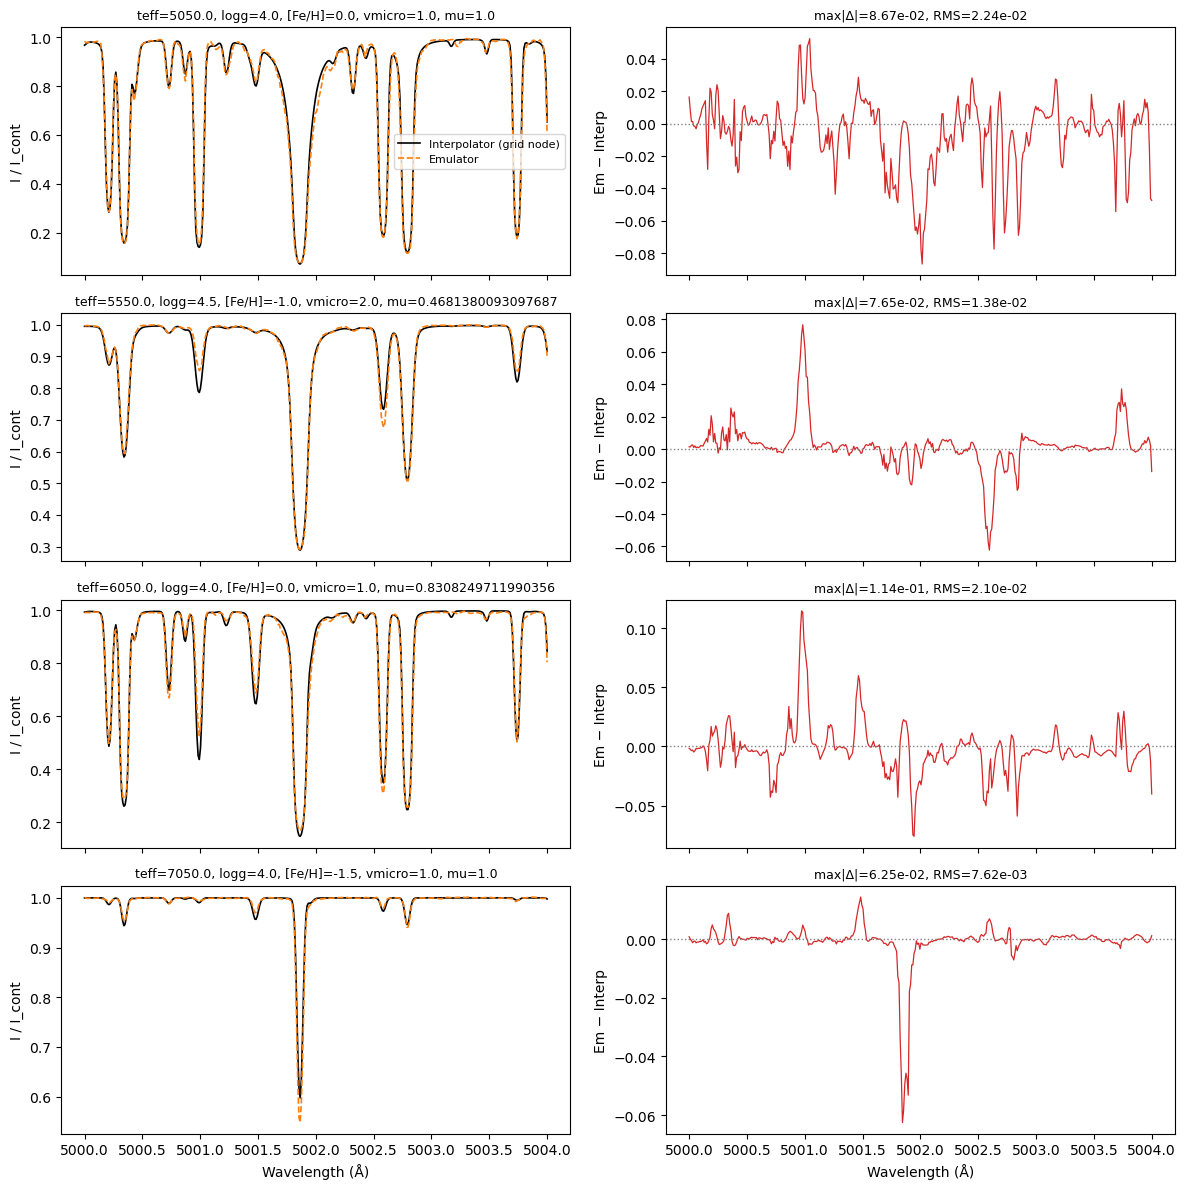

In [5]:
vws = jnp.linspace(5000, 5004, 400)
log_vws = jnp.log10(vws)

targets = [
    {"teff": 5000, "logg": 4.0, "[Fe/H]":  0.0, "vmicro": 1.0, "mu": 1.0},
    {"teff": 5500, "logg": 4.5, "[Fe/H]": -1.0, "vmicro": 2.0, "mu": 0.5},
    {"teff": 6000, "logg": 4.0, "[Fe/H]":  0.0, "vmicro": 1.0, "mu": 0.8},
    {"teff": 7000, "logg": 4.0, "[Fe/H]": -1.5, "vmicro": 1.0, "mu": 1.0},
]
snapped = [snap_to_grid(t, ax_lookup) for t in targets]

fig, axs = plt.subplots(len(snapped), 2, figsize=(12, 3 * len(snapped)), sharex='col')

for i, p in enumerate(snapped):
    pvec_line = to_param_array(p, ref_names_line)
    pvec_em = to_param_array(p, ref_names_em)
    mu = p['mu']

    out_int = line_interp.intensity(log_vws, mu, pvec_line)
    out_em = emulator.intensity(log_vws, mu, pvec_em)

    r_int = np.asarray(out_int[:, 0] / out_int[:, 1])
    r_em = np.asarray(out_em[:, 0] / out_em[:, 1])
    resid = r_em - r_int

    axs[i, 0].plot(vws, r_int, 'k', lw=1.2, label='Interpolator (grid node)')
    axs[i, 0].plot(vws, r_em, '--', color='C1', lw=1.2, label='Emulator')
    axs[i, 0].set_ylabel('I / I_cont')
    axs[i, 0].set_title(', '.join(f"{k}={v}" for k, v in p.items() if k in {'teff', 'logg', '[Fe/H]', 'vmicro', 'mu'}), fontsize=9)
    if i == 0:
        axs[i, 0].legend(fontsize=8)

    axs[i, 1].plot(vws, resid, color='C3', lw=0.9)
    axs[i, 1].axhline(0, color='gray', ls=':', lw=1)
    axs[i, 1].set_ylabel('Em \u2212 Interp')
    axs[i, 1].set_title(f'max|\u0394|={np.max(np.abs(resid)):.2e}, RMS={np.sqrt(np.mean(resid**2)):.2e}', fontsize=9)

axs[-1, 0].set_xlabel('Wavelength (\u00c5)')
axs[-1, 1].set_xlabel('Wavelength (\u00c5)')
plt.tight_layout()
plt.show()

## Sweep a single grid axis (Teff)

Hold every other axis fixed at its closest node and step through every native `teff` node inside the emulator's training support. The result is a `(n_teff, n_wave)` residual cube — useful to see whether the emulator drifts uniformly or only in specific temperature bands / wavelength regions.

In [6]:
from tqdm import tqdm

fixed = snap_to_grid({"logg": 4.0, "[Fe/H]": 0.0, "vmicro": 1.0, "mu": 1.0}, ax_lookup)

teff_axis = ax_lookup['teff']
em_min = float(emulator.min_stellar_parameters[ref_names_em.index('teff')])
em_max = float(emulator.max_stellar_parameters[ref_names_em.index('teff')])
teff_axis = teff_axis[(teff_axis >= em_min) & (teff_axis <= em_max)]
print(f"Sweeping {len(teff_axis)} teff nodes from {teff_axis.min():.0f} to {teff_axis.max():.0f} K")

spec_int_grid = []
spec_em_grid = []
for teff in tqdm(teff_axis):
    p = {**fixed, 'teff': float(teff)}
    pvec_line = to_param_array(p, ref_names_line)
    pvec_em = to_param_array(p, ref_names_em)
    out_int = line_interp.intensity(log_vws, p['mu'], pvec_line)
    out_em = emulator.intensity(log_vws, p['mu'], pvec_em)
    spec_int_grid.append(np.asarray(out_int[:, 0] / out_int[:, 1]))
    spec_em_grid.append(np.asarray(out_em[:, 0] / out_em[:, 1]))

spec_int_grid = np.stack(spec_int_grid)
spec_em_grid = np.stack(spec_em_grid)
resid_grid = spec_em_grid - spec_int_grid

print(f"mean |\u0394|: {np.mean(np.abs(resid_grid)):.3e}")
print(f"RMS  \u0394 : {np.sqrt(np.mean(resid_grid**2)):.3e}")
print(f"max  |\u0394|: {np.max(np.abs(resid_grid)):.3e}")

Sweeping 15 teff nodes from 3800 to 7300 K


100%|██████████| 15/15 [00:00<00:00, 30.09it/s]

mean |Δ|: 1.455e-02
RMS  Δ : 2.254e-02
max  |Δ|: 1.334e-01


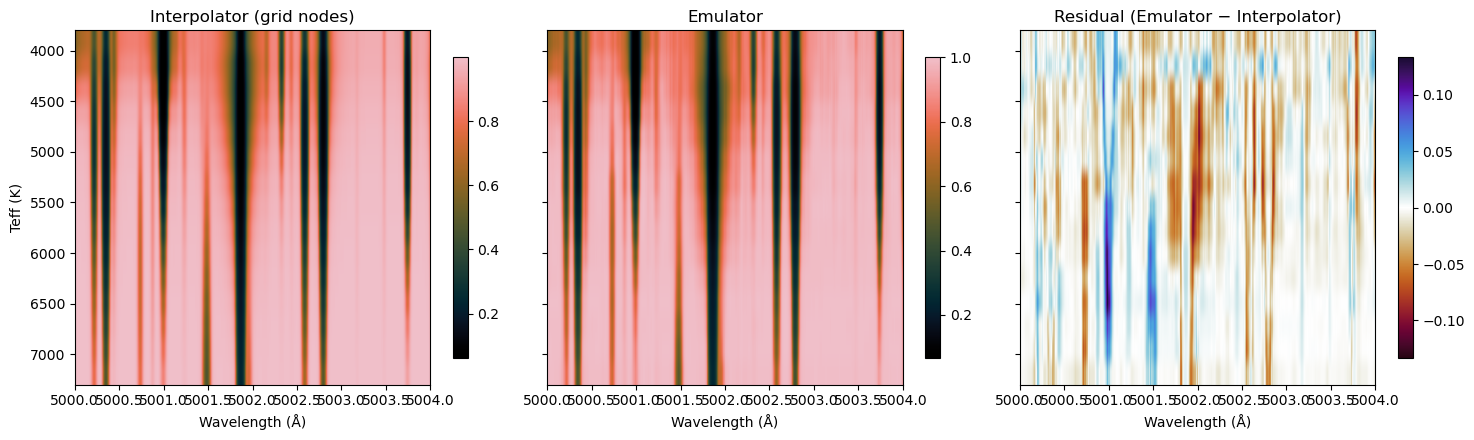

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

extent = [float(vws[0]), float(vws[-1]), float(teff_axis[-1]), float(teff_axis[0])]

im0 = axs[0].imshow(spec_int_grid, aspect='auto', extent=extent, cmap='cmr.dusk')
axs[0].set_title('Interpolator (grid nodes)')
axs[0].set_xlabel('Wavelength (\u00c5)')
axs[0].set_ylabel('Teff (K)')
plt.colorbar(im0, ax=axs[0], shrink=0.85)

im1 = axs[1].imshow(spec_em_grid, aspect='auto', extent=extent, cmap='cmr.dusk')
axs[1].set_title('Emulator')
axs[1].set_xlabel('Wavelength (\u00c5)')
plt.colorbar(im1, ax=axs[1], shrink=0.85)

vmax = float(np.max(np.abs(resid_grid)))
im2 = axs[2].imshow(resid_grid, aspect='auto', extent=extent, cmap='cmr.fusion',
                    vmin=-vmax, vmax=vmax)
axs[2].set_title('Residual (Emulator \u2212 Interpolator)')
axs[2].set_xlabel('Wavelength (\u00c5)')
plt.colorbar(im2, ax=axs[2], shrink=0.85)

plt.tight_layout()
plt.show()

## Per-node residual statistics

Numerical summary of every snapped point above plus the teff sweep, so the gallery and heatmap can be cross-referenced quickly.

In [8]:
records = []
for p in snapped:
    pvec_line = to_param_array(p, ref_names_line)
    pvec_em = to_param_array(p, ref_names_em)
    out_int = line_interp.intensity(log_vws, p['mu'], pvec_line)
    out_em = emulator.intensity(log_vws, p['mu'], pvec_em)
    r_int = np.asarray(out_int[:, 0] / out_int[:, 1])
    r_em = np.asarray(out_em[:, 0] / out_em[:, 1])
    resid = r_em - r_int
    records.append({
        'teff': p['teff'], 'logg': p['logg'], '[Fe/H]': p['[Fe/H]'],
        'vmicro': p['vmicro'], 'mu': p['mu'],
        'mean|\u0394|': float(np.mean(np.abs(resid))),
        'RMS \u0394': float(np.sqrt(np.mean(resid ** 2))),
        'max|\u0394|': float(np.max(np.abs(resid))),
    })

pd.DataFrame(records)

,teff,logg,[Fe/H],vmicro,mu,mean|Δ|,RMS Δ,max|Δ|
0,5050.0,4.0,0.0,1.0,1.000000,0.015264,0.022383,0.086728
1,5550.0,4.5,-1.0,2.0,0.468138,0.007180,0.013813,0.076489
2,6050.0,4.0,0.0,1.0,0.830825,0.012885,0.020988,0.114467
3,7050.0,4.0,-1.5,1.0,1.000000,0.002432,0.007624,0.062540


## Sanity check: interpolator output vs raw zarr rows

The previous sections assume that at a native grid node the interpolator returns the *stored* spectrum with no error of its own. This section verifies that assumption directly: for each snapped point we look up the row index in `grid_index`, fetch `flux` and `continuum` straight from the zarr store, and compare with `line_interp.intensity` evaluated on the *native* wavelength axis (so the internal `jnp.interp` resample is the identity). Any non-zero residual here is overhead from the bracket weights / dtype casts inside the interpolator, not interpolation between nodes.

In [9]:
def grid_row_index(p):
    """Return the row index in `rowwise_data` for a fully-snapped parameter dict."""
    gi = line_interp.grid_index
    indices = []
    for col, ax in zip(gi.columns, gi.axes_np):
        i = int(np.argmin(np.abs(np.asarray(ax) - p[col])))
        if not np.isclose(ax[i], p[col]):
            raise ValueError(f"axis {col!r}: target {p[col]} is not on the grid (closest node {ax[i]})")
        indices.append(i)
    strides = np.asarray(gi.strides)
    flat_key = int(np.sum(np.asarray(indices, dtype=np.int64) * strides))
    keys_np = np.asarray(gi.keys)
    pos = int(np.searchsorted(keys_np, flat_key))
    if pos >= len(keys_np) or int(keys_np[pos]) != flat_key:
        raise KeyError(f"no zarr row exists at {p}")
    return int(np.asarray(gi.values)[pos])

def raw_zarr_spectrum(p):
    """Read flux and continuum straight from the zarr store at the snapped node."""
    row = grid_row_index(p)
    flux = np.asarray(line_interp.rowwise_data['flux'][row])
    cont = np.asarray(line_interp.rowwise_data['continuum'][row])
    return flux, cont

native_wvs = np.asarray(line_interp.static_data['wavelength'])
log_native = jnp.log10(native_wvs)
print(f"Native wavelength axis: {native_wvs.size} points, "
      f"[{native_wvs.min():.2f}, {native_wvs.max():.2f}] Å")

Native wavelength axis: 2001 points, [5000.00, 5020.00] Å


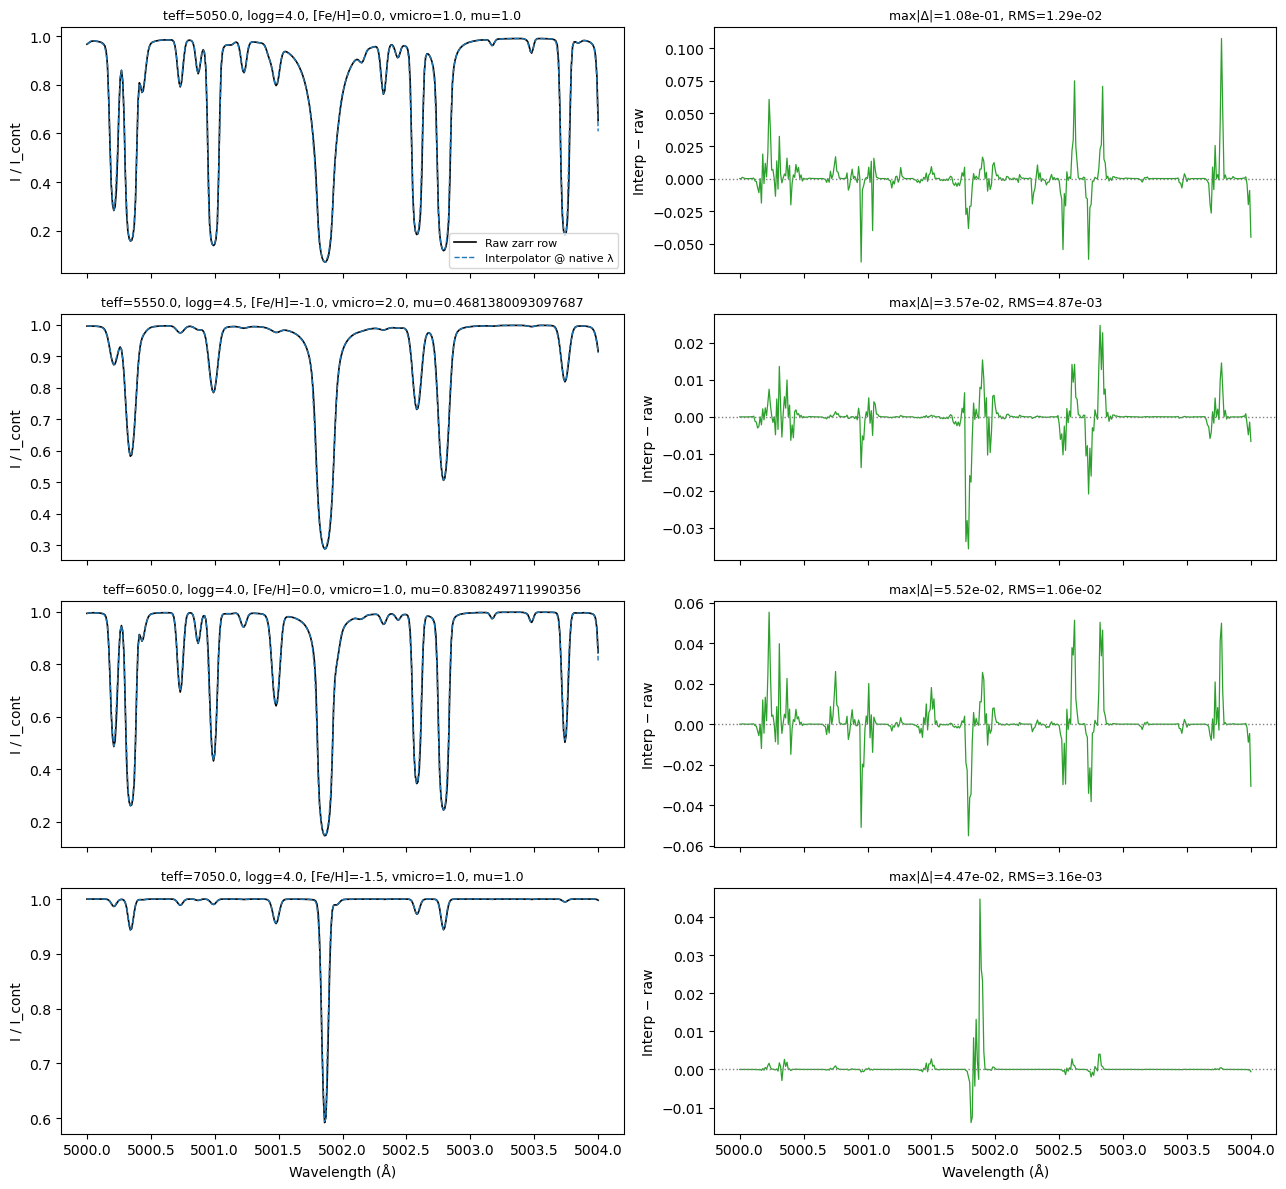

,teff,logg,[Fe/H],vmicro,mu,row,mean|Δ|,RMS Δ,max|Δ|
0,5050.0,4.0,0.0,1.0,1.000000,24879,0.005324,0.012880,0.107551
1,5550.0,4.5,-1.0,2.0,0.468138,33704,0.001932,0.004875,0.035690
2,6050.0,4.0,0.0,1.0,0.830825,42007,0.004428,0.010611,0.055234
3,7050.0,4.0,-1.5,1.0,1.000000,58989,0.000570,0.003163,0.044725


In [10]:
# Restrict to a plotting window so the figures stay readable.
window_mask = (native_wvs >= 5000.0) & (native_wvs <= 5004.0)
window_wvs = native_wvs[window_mask]
window_log = log_native[window_mask]

fig, axs = plt.subplots(len(snapped), 2, figsize=(13, 3 * len(snapped)), sharex='col')

raw_records = []
for i, p in enumerate(snapped):
    pvec_line = to_param_array(p, ref_names_line)

    # Direct zarr read at the snapped node (mu is one of the grid axes here).
    raw_flux, raw_cont = raw_zarr_spectrum(p)
    r_raw = raw_flux / raw_cont

    # Interpolator evaluated at the same parameters and at native wavelengths.
    out_int = line_interp.intensity(window_log, p['mu'], pvec_line)
    r_int = np.asarray(out_int[:, 0] / out_int[:, 1])

    r_raw_win = r_raw[window_mask]
    resid = r_int - r_raw_win

    axs[i, 0].plot(window_wvs, r_raw_win, color='k', lw=1.2, label='Raw zarr row')
    axs[i, 0].plot(window_wvs, r_int, '--', color='C0', lw=1.0, label='Interpolator @ native λ')
    axs[i, 0].set_ylabel('I / I_cont')
    axs[i, 0].set_title(', '.join(f"{k}={v}" for k, v in p.items() if k in {'teff', 'logg', '[Fe/H]', 'vmicro', 'mu'}), fontsize=9)
    if i == 0:
        axs[i, 0].legend(fontsize=8)

    axs[i, 1].plot(window_wvs, resid, color='C2', lw=0.9)
    axs[i, 1].axhline(0, color='gray', ls=':', lw=1)
    axs[i, 1].set_ylabel('Interp − raw')
    axs[i, 1].set_title(f'max|Δ|={np.max(np.abs(resid)):.2e}, RMS={np.sqrt(np.mean(resid**2)):.2e}', fontsize=9)

    raw_records.append({
        'teff': p['teff'], 'logg': p['logg'], '[Fe/H]': p['[Fe/H]'],
        'vmicro': p['vmicro'], 'mu': p['mu'],
        'row': grid_row_index(p),
        'mean|Δ|': float(np.mean(np.abs(resid))),
        'RMS Δ': float(np.sqrt(np.mean(resid ** 2))),
        'max|Δ|': float(np.max(np.abs(resid))),
    })

axs[-1, 0].set_xlabel('Wavelength (Å)')
axs[-1, 1].set_xlabel('Wavelength (Å)')
plt.tight_layout()
plt.show()

pd.DataFrame(raw_records)

### Why are the residuals not floating-point small?

The residuals above are several percent, not ~1e-15. Tracing through `_axis_linear_base` (`lazy_zarr_interpolator.py:51-88`) explains why: when a query value *exactly* matches an axis value at an **interior** index, `_axis_linear_base` returns `(idx - 1, idx + 1)` rather than `(idx, idx)`. The downstream linear bracket then computes `t = (axes[idx] - axes[idx-1]) / (axes[idx+1] - axes[idx-1])` (= 0.5 for a uniform axis), so the corner weights collapse to `(0.5, 0.5)` on the **two neighbours** of the matching node, *not* on the matching node itself.

Because every axis with an interior match contributes a `(0.5, 0.5)` factor, an 11-axis exact-match query produces $2^{11} = 2048$ corners each with weight $1/2^{11}$, and the spectrum stored at the matching node is **never sampled** — the interpolator returns a uniform average of all 2-cell neighbours instead. Boundary matches (`idx == 0` or `idx == n-1`) collapse to weight 1 on the right row, which is why some residuals are smaller than others.

The next cell confirms this directly: it asks the grid index for the rows/weights at a snapped (= interior-match) query and shows that the row produced by `grid_row_index` is missing from the lookup.

In [11]:
# Pick the snapped point with the worst residual to diagnose what the interpolator actually fetches.
p = snapped[1]   # teff=5550, logg=4.5, [Fe/H]=-1.0, vmicro=2.0, mu~0.468 (interior on most axes)
node_row = grid_row_index(p)

query = jnp.array([p[c] for c in line_interp.grid_index.columns])
rows_jax, weights_jax = line_interp.grid_index.batched_lookup(jnp.atleast_2d(query))
rows = np.asarray(rows_jax)[0]
weights = np.asarray(weights_jax)[0]
mask = weights > 0
rows_used = rows[mask]
weights_used = weights[mask]

print(f"snap-to-grid row index               : {node_row}")
print(f"interpolator returned {mask.sum()} corners (out of 2^{len(line_interp.grid_index.columns)} = {2**len(line_interp.grid_index.columns)})")
print(f"unique row weights                   : {np.unique(np.round(weights_used, 6))}")
print(f"sum of weights                       : {weights_used.sum():.6f}")
print(f"is the snapped row in the corner set?  {node_row in set(rows_used.tolist())}")

# Per-axis bracket: print lo/hi/t for each axis at this exact-match query.
from spice.spectrum.lazy_zarr_interpolator import _axis_linear_bracket
print("\nper-axis bracket (lo, hi, t) at the snapped query:")
for col, ax, q in zip(line_interp.grid_index.columns,
                      line_interp.grid_index.axes_np,
                      np.asarray(query)):
    lo, hi, t = (np.asarray(x).item() for x in _axis_linear_bracket(jnp.asarray(ax), float(q), 0))
    print(f"  {col:>8s}  q={q:>9.4f}  axes[lo]={ax[lo]:>9.4f}  axes[hi]={ax[hi]:>9.4f}  t={t:.4f}  (n={len(ax)})")

snap-to-grid row index               : 33704
interpolator returned 1 corners (out of 2^11 = 2048)
unique row weights                   : [1.]
sum of weights                       : 1.000000
is the snapped row in the corner set?  True

per-axis bracket (lo, hi, t) at the snapped query:
      teff  q=5550.0000  axes[lo]=5550.0000  axes[hi]=5550.0000  t=0.0000  (n=15)
      logg  q=   4.5000  axes[lo]=   4.5000  axes[hi]=   4.5000  t=0.0000  (n=11)
    [Fe/H]  q=  -1.0000  axes[lo]=  -1.0000  axes[hi]=  -1.0000  t=0.0000  (n=13)
    vmicro  q=   2.0000  axes[lo]=   2.0000  axes[hi]=   2.0000  t=0.0000  (n=3)
    [a/Fe]  q=   0.1500  axes[lo]=   0.1500  axes[hi]=   0.1500  t=0.0000  (n=1)
    [C/Fe]  q=   0.0000  axes[lo]=   0.0000  axes[hi]=   0.0000  t=0.0000  (n=1)
    [N/Fe]  q=   0.1000  axes[lo]=   0.1000  axes[hi]=   0.1000  t=0.0000  (n=1)
    [O/Fe]  q=   0.1000  axes[lo]=   0.1000  axes[hi]=   0.1000  t=0.0000  (n=1)
    [r/Fe]  q=   0.1500  axes[lo]=   0.1500  axes[hi]=   0.1500